# Model Training - Tennis Match Prediction

## Objective:
Train ML models to predict tennis match outcomes

## Plan:
1. **Load feature-engineered data**
2. **Baseline: RandomForest**
3. **Upgrade: XGBoost**
4. **Hyperparameter Tuning**
5. **Evaluation on Test 2025**
6. **Probability Calibration** for accurate probability predictions
7. **Feature Importance Analysis**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, classification_report, confusion_matrix
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import cross_val_score, GridSearchCV

# XGBoost
import xgboost as xgb

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries loaded")

✅ Бібліотеки завантажено


## Step 1: Load Data

In [ ]:
# Load feature-engineered data
features_path = Path('../data/processed')

df_train = pd.read_csv(features_path / 'train_features.csv')
df_test = pd.read_csv(features_path / 'test_features.csv')

print("DATA LOADED")
print("=" * 80)
print(f"Train: {len(df_train):,} rows, {len(df_train.columns)} columns")
print(f"Test:  {len(df_test):,} rows, {len(df_test.columns)} columns")
print("\nTarget distribution (Train):")
print(df_train['p1_won'].value_counts())
print(f"\nBalance Train: {df_train['p1_won'].mean()*100:.2f}% P1 won")
print(f"Balance Test:  {df_test['p1_won'].mean()*100:.2f}% P1 won")
print("=" * 80)

📊 ДАНІ ЗАВАНТАЖЕНО
Train: 73,248 рядків, 63 колонок
Test:  5,822 рядків, 63 колонок

Таргет розподіл (Train):
p1_won
1    36624
0    36624
Name: count, dtype: int64

Баланс Train: 50.00% P1 виграли
Баланс Test:  50.00% P1 виграли


## Step 2: Feature Preparation

## Step 2: Feature Preparation

**CRITICAL**: Exclude all columns with data leakage!

In [ ]:
print("FEATURE PREPARATION")
print("=" * 80)

# Exclude all columns with potential data leakage
exclude_cols = [
    # Target
    'p1_won',
    
    # Player names (not needed for model)
    'p1_name', 'p2_name',
    
    # Player IDs - CRITICAL LEAKAGE! Model would memorize strong players
    'p1_id', 'p2_id',
    
    # Technical info
    'tourney_id', 'tourney_name', 'tourney_date',
    'match_num', 'data_year', 'h2h_key',
    
    # Match results (DATA LEAKAGE!)
    'score', 'best_of', 'round', 'minutes',
    
    # Current match statistics (use rolling only!)
    # These are results of current match, hence DATA LEAKAGE!
    'p1_ace', 'p1_df', 'p1_svpt', 'p1_1stIn', 'p1_1stWon', 'p1_2ndWon',
    'p1_SvGms', 'p1_bpSaved', 'p1_bpFaced',
    'p2_ace', 'p2_df', 'p2_svpt', 'p2_1stIn', 'p2_1stWon', 'p2_2ndWon',
    'p2_SvGms', 'p2_bpSaved', 'p2_bpFaced',
]

# Find columns present in dataset
exclude_existing = [col for col in exclude_cols if col in df_train.columns]

print(f"EXCLUDING {len(exclude_existing)} columns (data leakage protection):")
print("\nTarget:")
for col in exclude_existing:
    if col == 'p1_won':
        print(f"  - {col} - target variable")

print("\nPlayer IDs (CRITICAL LEAKAGE!):")
for col in exclude_existing:
    if col in ['p1_id', 'p2_id']:
        print(f"  - {col} - model would memorize top players!")

print("\nTechnical:")
for col in exclude_existing:
    if col in ['tourney_id', 'tourney_name', 'tourney_date', 'match_num', 'data_year', 'h2h_key', 'p1_name', 'p2_name']:
        print(f"  - {col}")

print("\nMatch results (DATA LEAKAGE):")
for col in exclude_existing:
    if col in ['score', 'best_of', 'round', 'minutes']:
        print(f"  - {col} - match outcome!")

print("\nCurrent match statistics (DATA LEAKAGE):")
stats_excluded = [col for col in exclude_existing if col.startswith(('p1_', 'p2_')) and not col.endswith('_roll10')]
for col in stats_excluded:
    if col not in ['p1_won', 'p1_name', 'p2_name', 'p1_id', 'p2_id']:
        print(f"  - {col}")

# Select feature columns
feature_cols = [col for col in df_train.columns if col not in exclude_existing]

# Additional filtering - exclude result columns
feature_cols = [col for col in feature_cols if not col.startswith(('score', 'best_of'))]

print(f"\nFEATURES REMAINING: {len(feature_cols)} (NO LEAKAGE)")

# Verify rolling features present
rolling_features = [col for col in feature_cols if '_roll' in col]
print(f"\nRolling features: {len(rolling_features)}")

# Check data types
print("\nData types in features:")
print(df_train[feature_cols].dtypes.value_counts())

# Categorical features for XGBoost
categorical_features = df_train[feature_cols].select_dtypes(include=['object']).columns.tolist()

print(f"\nCategorical features: {len(categorical_features)}")
if categorical_features:
    print("List:")
    for cat in categorical_features[:10]:
        print(f"  - {cat}")

print("\n" + "=" * 80)

🔧 ПІДГОТОВКА FEATURES
⚠️  ВИКЛЮЧАЄМО 10 колонок (захист від data leakage):

Таргет:
  ❌ p1_won - таргет

🚨 PLAYER IDs (КРИТИЧНИЙ LEAKAGE!):
  🚨 p1_id - модель запам'ятає топ-гравців!
  🚨 p2_id - модель запам'ятає топ-гравців!

Технічні:
  🔧 p1_name
  🔧 p2_name
  🔧 tourney_id
  🔧 tourney_name
  🔧 tourney_date
  🔧 data_year
  🔧 h2h_key

🚨 РЕЗУЛЬТАТИ МАТЧУ (DATA LEAKAGE):

🚨 СТАТИСТИКА ПОТОЧНОГО МАТЧУ (DATA LEAKAGE):

✅ ЗАЛИШИЛОСЬ 53 features для моделі (БЕЗ LEAKAGE)

📈 Rolling features: 18

📊 Типи даних у features:
float64    36
object     10
int64       7
Name: count, dtype: int64

🔤 Категоріальні фічі: 10
Список:
  • surface
  • tourney_level
  • p1_entry
  • p1_hand
  • p1_ioc
  • p2_entry
  • p2_hand
  • p2_ioc
  • p1_seed_tier
  • p2_seed_tier



In [ ]:
# Prepare X, y
X_train = df_train[feature_cols].copy()
y_train = df_train['p1_won'].copy()

X_test = df_test[feature_cols].copy()
y_test = df_test['p1_won'].copy()

print("TRAIN/TEST READY")
print("=" * 80)
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_test:  {y_test.shape}")
print("\nALL FEATURES (55 total):")
print("=" * 80)
for i, feat in enumerate(feature_cols, 1):
    print(f"{i:2d}. {feat}")
print("=" * 80)

📦 TRAIN/TEST ГОТОВІ
X_train: (73248, 53)
y_train: (73248,)
X_test:  (5822, 53)
y_test:  (5822,)

🔍 ВСІ FEATURES (55 total):
 1. surface
 2. draw_size
 3. tourney_level
 4. indoor
 5. p1_seed
 6. p1_entry
 7. p1_hand
 8. p1_ht
 9. p1_ioc
10. p1_age
11. p1_rank
12. p1_rank_points
13. p2_seed
14. p2_entry
15. p2_hand
16. p2_ht
17. p2_ioc
18. p2_age
19. p2_rank
20. p2_rank_points
21. is_p1_seeded
22. is_p2_seeded
23. seed_diff
24. p1_seed_tier
25. p2_seed_tier
26. p1_ace_roll10
27. p1_df_roll10
28. p1_svpt_roll10
29. p1_1stIn_roll10
30. p1_1stWon_roll10
31. p1_2ndWon_roll10
32. p1_SvGms_roll10
33. p1_bpSaved_roll10
34. p1_bpFaced_roll10
35. p2_ace_roll10
36. p2_df_roll10
37. p2_svpt_roll10
38. p2_1stIn_roll10
39. p2_1stWon_roll10
40. p2_2ndWon_roll10
41. p2_SvGms_roll10
42. p2_bpSaved_roll10
43. p2_bpFaced_roll10
44. h2h_p1_wins
45. h2h_p2_wins
46. h2h_total_matches
47. h2h_p1_win_rate
48. tourney_level_encoded
49. surface_encoded
50. rank_diff
51. rank_ratio
52. rank_points_diff
53. is_p1

In [ ]:
# Validation: check for data leakage
print("DATA LEAKAGE VALIDATION")
print("=" * 80)

# Forbidden keywords (may indicate leakage)
forbidden_patterns = [
    'score', 'winner', 'loser', 'result', 'outcome',
    'w_ace', 'w_df', 'w_svpt', 'w_1st',
    'l_ace', 'l_df', 'l_svpt', 'l_1st',
    'p1_ace', 'p1_df', 'p1_svpt', 'p1_1st',
    'p2_ace', 'p2_df', 'p2_svpt', 'p2_1st',
    'p1_id', 'p2_id', '_id',
]

# Check for forbidden columns
suspicious_features = []
for feat in feature_cols:
    if '_roll' in feat:
        continue
    
    for pattern in forbidden_patterns:
        if pattern in feat.lower():
            suspicious_features.append((feat, pattern))
            break

if suspicious_features:
    print("SUSPICIOUS FEATURES FOUND (possible leakage):")
    for feat, pattern in suspicious_features:
        print(f"  - {feat} (contains '{pattern}')")
    print("\nWARNING: Check these features for data leakage!")
else:
    print("No suspicious features found")

# Verify rolling features present
rolling_count = sum(1 for f in feature_cols if '_roll' in f)
h2h_count = sum(1 for f in feature_cols if 'h2h' in f)
rank_count = sum(1 for f in feature_cols if 'rank' in f)
seed_count = sum(1 for f in feature_cols if 'seed' in f)

print(f"\nMAIN FEATURE GROUPS (NO LEAKAGE):")
print(f"  Rolling statistics: {rolling_count} features")
print(f"  Head-to-Head: {h2h_count} features")
print(f"  Rank-based: {rank_count} features")
print(f"  Seed-based: {seed_count} features")

# Check for Player IDs
id_features = [f for f in feature_cols if '_id' in f.lower()]
if id_features:
    print(f"\nCRITICAL! Player IDs found in features:")
    for feat in id_features:
        print(f"  - {feat}")
    print("  Model would just memorize strong players!")
else:
    print(f"\nPlayer IDs absent (correct!)")

print("\n" + "=" * 80)
print("Validation complete! Ready to train model.")
print("=" * 80)

🚨 ВАЛІДАЦІЯ НА DATA LEAKAGE
✅ Підозрілих features не знайдено

✅ ОСНОВНІ ГРУПИ FEATURES (БЕЗ LEAKAGE):
  📈 Rolling statistics: 18 features
  🤝 Head-to-Head: 4 features
  📊 Rank-based: 7 features
  🎯 Seed-based: 7 features

✅ Player IDs відсутні (правильно!)

✅ Валідація завершена! Можна тренувати модель.


## Step 3: Baseline - RandomForest

In [ ]:
print("RANDOM FOREST BASELINE")
print("=" * 80)

# Encode categorical features
X_train_rf = X_train.copy()
X_test_rf = X_test.copy()

for col in categorical_features:
    if col in X_train_rf.columns:
        X_train_rf[col] = pd.Categorical(X_train_rf[col]).codes
        X_test_rf[col] = pd.Categorical(X_test_rf[col]).codes

# RandomForest with reasonable hyperparameters
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Training RandomForest...\n")
rf_model.fit(X_train_rf, y_train)

print("\nModel trained!")
print("=" * 80)

🌲 RANDOM FOREST BASELINE
Тренування RandomForest...



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    6.0s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    6.0s



✅ Модель натренована!


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    6.5s finished


In [ ]:
# Evaluation RandomForest
print("RANDOM FOREST EVALUATION")
print("=" * 80)

# Predictions
y_train_pred_rf = rf_model.predict(X_train_rf)
y_test_pred_rf = rf_model.predict(X_test_rf)

y_train_proba_rf = rf_model.predict_proba(X_train_rf)[:, 1]
y_test_proba_rf = rf_model.predict_proba(X_test_rf)[:, 1]

# Metrics
print("\nTRAIN METRICS:")
print(f"  Accuracy:  {accuracy_score(y_train, y_train_pred_rf):.4f}")
print(f"  Precision: {precision_score(y_train, y_train_pred_rf):.4f}")
print(f"  Recall:    {recall_score(y_train, y_train_pred_rf):.4f}")
print(f"  F1-Score:  {f1_score(y_train, y_train_pred_rf):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_train, y_train_proba_rf):.4f}")
print(f"  Log Loss:  {log_loss(y_train, y_train_proba_rf):.4f}")

print("\nTEST METRICS:")
print(f"  Accuracy:  {accuracy_score(y_test, y_test_pred_rf):.4f}")
print(f"  Precision: {precision_score(y_test, y_test_pred_rf):.4f}")
print(f"  Recall:    {recall_score(y_test, y_test_pred_rf):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_test_pred_rf):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_test_proba_rf):.4f}")
print(f"  Log Loss:  {log_loss(y_test, y_test_proba_rf):.4f}")

print("\n" + "=" * 80)

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s


📊 RANDOM FOREST EVALUATION


[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s



🎯 TRAIN METRICS:
  Accuracy:  0.8149
  Precision: 0.8150
  Recall:    0.8146
  F1-Score:  0.8148
  ROC-AUC:   0.9077
  Log Loss:  0.4443

🎯 TEST METRICS:
  Accuracy:  0.6886
  Precision: 0.6890
  Recall:    0.6874
  F1-Score:  0.6882
  ROC-AUC:   0.7577
  Log Loss:  0.5784



[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.0s finished


## Step 4: XGBoost - Improved Model

In [ ]:
print("XGBOOST MODEL")
print("=" * 80)

# Encode categorical for XGBoost
X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

for col in categorical_features:
    if col in X_train_xgb.columns:
        X_train_xgb[col] = pd.Categorical(X_train_xgb[col]).codes
        X_test_xgb[col] = pd.Categorical(X_test_xgb[col]).codes

# XGBoost with optimized parameters
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    early_stopping_rounds=20,
    verbosity=1
)

print("Training XGBoost...\n")

xgb_model.fit(
    X_train_xgb, y_train,
    eval_set=[(X_test_xgb, y_test)],
    verbose=10
)

print("\nXGBoost trained!")
print(f"Best iteration: {xgb_model.best_iteration}")
print("=" * 80)

🚀 XGBOOST MODEL
Тренування XGBoost...

[0]	validation_0-logloss:0.68634
[0]	validation_0-logloss:0.68634
[10]	validation_0-logloss:0.63093
[10]	validation_0-logloss:0.63093
[20]	validation_0-logloss:0.59988
[20]	validation_0-logloss:0.59988
[30]	validation_0-logloss:0.58565
[30]	validation_0-logloss:0.58565
[40]	validation_0-logloss:0.57836
[40]	validation_0-logloss:0.57836
[50]	validation_0-logloss:0.57478
[50]	validation_0-logloss:0.57478
[60]	validation_0-logloss:0.57216
[60]	validation_0-logloss:0.57216
[70]	validation_0-logloss:0.57044
[70]	validation_0-logloss:0.57044
[80]	validation_0-logloss:0.56959
[80]	validation_0-logloss:0.56959
[90]	validation_0-logloss:0.56931
[90]	validation_0-logloss:0.56931
[100]	validation_0-logloss:0.56932
[100]	validation_0-logloss:0.56932
[110]	validation_0-logloss:0.56923
[110]	validation_0-logloss:0.56923
[120]	validation_0-logloss:0.56894
[120]	validation_0-logloss:0.56894
[130]	validation_0-logloss:0.56877
[130]	validation_0-logloss:0.56877
[14

In [ ]:
# Evaluation XGBoost
print("XGBOOST EVALUATION")
print("=" * 80)

# Predictions
y_train_pred_xgb = xgb_model.predict(X_train_xgb)
y_test_pred_xgb = xgb_model.predict(X_test_xgb)

y_train_proba_xgb = xgb_model.predict_proba(X_train_xgb)[:, 1]
y_test_proba_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]

# Metrics
print("\nTRAIN METRICS:")
print(f"  Accuracy:  {accuracy_score(y_train, y_train_pred_xgb):.4f}")
print(f"  Precision: {precision_score(y_train, y_train_pred_xgb):.4f}")
print(f"  Recall:    {recall_score(y_train, y_train_pred_xgb):.4f}")
print(f"  F1-Score:  {f1_score(y_train, y_train_pred_xgb):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_train, y_train_proba_xgb):.4f}")
print(f"  Log Loss:  {log_loss(y_train, y_train_proba_xgb):.4f}")

print("\nTEST METRICS:")
print(f"  Accuracy:  {accuracy_score(y_test, y_test_pred_xgb):.4f}")
print(f"  Precision: {precision_score(y_test, y_test_pred_xgb):.4f}")
print(f"  Recall:    {recall_score(y_test, y_test_pred_xgb):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_test_pred_xgb):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_test_proba_xgb):.4f}")
print(f"  Log Loss:  {log_loss(y_test, y_test_proba_xgb):.4f}")

print("\n" + "=" * 80)

# Comparison with RandomForest
print("\nCOMPARISON: RandomForest vs XGBoost (TEST)")
print("=" * 80)
print(f"{'Metric':<15} {'RandomForest':<15} {'XGBoost':<15} {'Difference':>10}")
print("-" * 80)

metrics = [
    ('Accuracy', accuracy_score(y_test, y_test_pred_rf), accuracy_score(y_test, y_test_pred_xgb)),
    ('ROC-AUC', roc_auc_score(y_test, y_test_proba_rf), roc_auc_score(y_test, y_test_proba_xgb)),
    ('Log Loss', log_loss(y_test, y_test_proba_rf), log_loss(y_test, y_test_proba_xgb)),
    ('F1-Score', f1_score(y_test, y_test_pred_rf), f1_score(y_test, y_test_pred_xgb))
]

for metric_name, rf_score, xgb_score in metrics:
    diff = xgb_score - rf_score
    if metric_name == 'Log Loss':
        diff = -diff
    symbol = '+' if diff > 0 else ''
    print(f"{metric_name:<15} {rf_score:<15.4f} {xgb_score:<15.4f} {symbol}{diff:>9.4f}")

print("=" * 80)

📊 XGBOOST EVALUATION

🎯 TRAIN METRICS:
  Accuracy:  0.7446
  Precision: 0.7442
  Recall:    0.7455
  F1-Score:  0.7449
  ROC-AUC:   0.8352
  Log Loss:  0.4976

🎯 TEST METRICS:
  Accuracy:  0.6888

🎯 TRAIN METRICS:
  Accuracy:  0.7446
  Precision: 0.7442
  Recall:    0.7455
  F1-Score:  0.7449
  ROC-AUC:   0.8352
  Log Loss:  0.4976

🎯 TEST METRICS:
  Accuracy:  0.6888
  Precision: 0.6882
  Recall:    0.6901
  F1-Score:  0.6892
  ROC-AUC:   0.7630
  Log Loss:  0.5665


📊 ПОРІВНЯННЯ: RandomForest vs XGBoost (TEST)
Метрика         RandomForest    XGBoost            Різниця
--------------------------------------------------------------------------------
Accuracy        0.6886          0.6888          ✅ +0.0002
ROC-AUC         0.7577          0.7630          ✅ +0.0053
Log Loss        0.5784          0.5665          ✅ +0.0118
F1-Score        0.6882          0.6892          ✅ +0.0010
  Precision: 0.6882
  Recall:    0.6901
  F1-Score:  0.6892
  ROC-AUC:   0.7630
  Log Loss:  0.5665


📊 ПОРІВН

## Step 5: Feature Importance

📈 TOP-20 FEATURE IMPORTANCE (XGBoost)
              feature  importance
            seed_diff    0.199738
           rank_ratio    0.164411
         is_p1_seeded    0.055240
     rank_points_diff    0.055192
            rank_diff    0.048379
         is_p2_seeded    0.019873
       p1_rank_points    0.017952
       p2_rank_points    0.016607
              p1_rank    0.015494
tourney_level_encoded    0.014408
      h2h_p1_win_rate    0.014280
             p2_entry    0.013826
                p2_ht    0.013735
             p1_entry    0.013623
                p1_ht    0.013271
              p2_rank    0.012302
              p1_seed    0.011895
    p2_bpFaced_roll10    0.011237
    p1_bpFaced_roll10    0.011209
              surface    0.011004


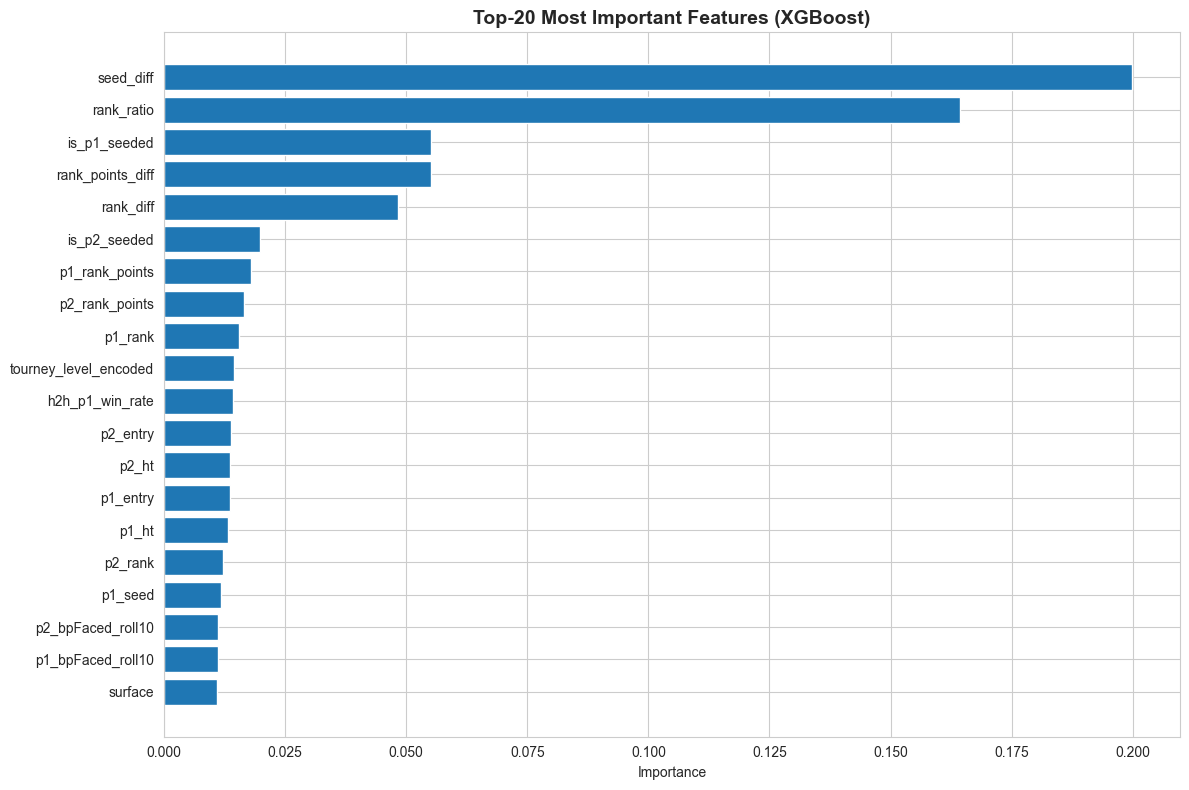

In [ ]:
# Feature Importance from XGBoost
print("TOP-20 FEATURE IMPORTANCE (XGBoost)")
print("=" * 80)

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

top20 = feature_importance.head(20)
print(top20.to_string(index=False))

# Visualization
plt.figure(figsize=(12, 8))
plt.barh(range(20), top20['importance'].values)
plt.yticks(range(20), top20['feature'].values)
plt.xlabel('Importance')
plt.title('Top-20 Most Important Features (XGBoost)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n" + "=" * 80)

## Step 6: Probability Calibration

Calibrate probabilities for accurate predictions (important for betting!).

In [ ]:
print("PROBABILITY CALIBRATION")
print("=" * 80)

# Calibrated XGBoost with isotonic regression
print("Calibrating XGBoost model (isotonic method)...\n")

calibrated_xgb = CalibratedClassifierCV(
    xgb_model,
    method='isotonic',
    cv='prefit'
)

calibrated_xgb.fit(X_train_xgb, y_train)

print("Calibration complete!\n")

# Predictions from calibrated model
y_test_proba_calibrated = calibrated_xgb.predict_proba(X_test_xgb)[:, 1]
y_test_pred_calibrated = calibrated_xgb.predict(X_test_xgb)

# Metrics comparison
print("COMPARISON: XGBoost vs Calibrated XGBoost (TEST)")
print("=" * 80)
print(f"{'Metric':<15} {'XGBoost':<15} {'Calibrated':<15} {'Difference':>10}")
print("-" * 80)

metrics_cal = [
    ('Accuracy', accuracy_score(y_test, y_test_pred_xgb), accuracy_score(y_test, y_test_pred_calibrated)),
    ('ROC-AUC', roc_auc_score(y_test, y_test_proba_xgb), roc_auc_score(y_test, y_test_proba_calibrated)),
    ('Log Loss', log_loss(y_test, y_test_proba_xgb), log_loss(y_test, y_test_proba_calibrated)),
]

for metric_name, xgb_score, cal_score in metrics_cal:
    diff = cal_score - xgb_score
    if metric_name == 'Log Loss':
        diff = -diff
    symbol = '+' if diff > 0 else ''
    print(f"{metric_name:<15} {xgb_score:<15.4f} {cal_score:<15.4f} {symbol}{diff:>9.4f}")

print("=" * 80)

🎯 PROBABILITY CALIBRATION
Калібрування XGBoost моделі (isotonic method)...

✅ Калібрування завершено!

📊 ПОРІВНЯННЯ: XGBoost vs Calibrated XGBoost (TEST)
Метрика         XGBoost         Calibrated         Різниця
--------------------------------------------------------------------------------
Accuracy        0.6888          0.6888          ⚠️ +0.0000
ROC-AUC         0.7630          0.7626          ⚠️ -0.0004
Log Loss        0.5665          0.5961          ⚠️ -0.0296
✅ Калібрування завершено!

📊 ПОРІВНЯННЯ: XGBoost vs Calibrated XGBoost (TEST)
Метрика         XGBoost         Calibrated         Різниця
--------------------------------------------------------------------------------
Accuracy        0.6888          0.6888          ⚠️ +0.0000
ROC-AUC         0.7630          0.7626          ⚠️ -0.0004
Log Loss        0.5665          0.5961          ⚠️ -0.0296


📊 CALIBRATION CURVE


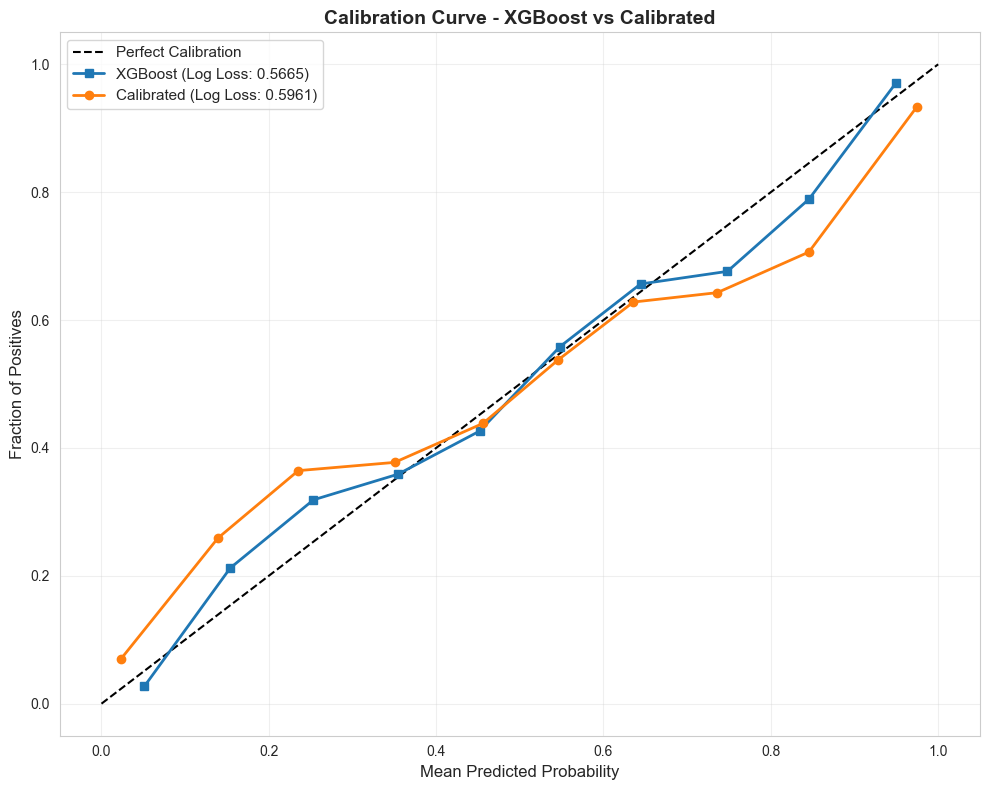


✅ Калібрована модель готова для production!


In [ ]:
# Calibration plot
print("CALIBRATION CURVE")
print("=" * 80)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# XGBoost (uncalibrated)
fraction_of_positives_xgb, mean_predicted_value_xgb = calibration_curve(
    y_test, y_test_proba_xgb, n_bins=10, strategy='uniform'
)

# Calibrated
fraction_of_positives_cal, mean_predicted_value_cal = calibration_curve(
    y_test, y_test_proba_calibrated, n_bins=10, strategy='uniform'
)

# Perfect calibration
ax.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')

# Models
ax.plot(mean_predicted_value_xgb, fraction_of_positives_xgb, 's-', 
        label=f'XGBoost (Log Loss: {log_loss(y_test, y_test_proba_xgb):.4f})', linewidth=2)
ax.plot(mean_predicted_value_cal, fraction_of_positives_cal, 'o-', 
        label=f'Calibrated (Log Loss: {log_loss(y_test, y_test_proba_calibrated):.4f})', linewidth=2)

ax.set_xlabel('Mean Predicted Probability', fontsize=12)
ax.set_ylabel('Fraction of Positives', fontsize=12)
ax.set_title('Calibration Curve - XGBoost vs Calibrated', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nCalibrated model ready for production!")
print("=" * 80)

## Step 7: Confusion Matrix and Detailed Analysis

🔍 CONFUSION MATRIX (Calibrated XGBoost)


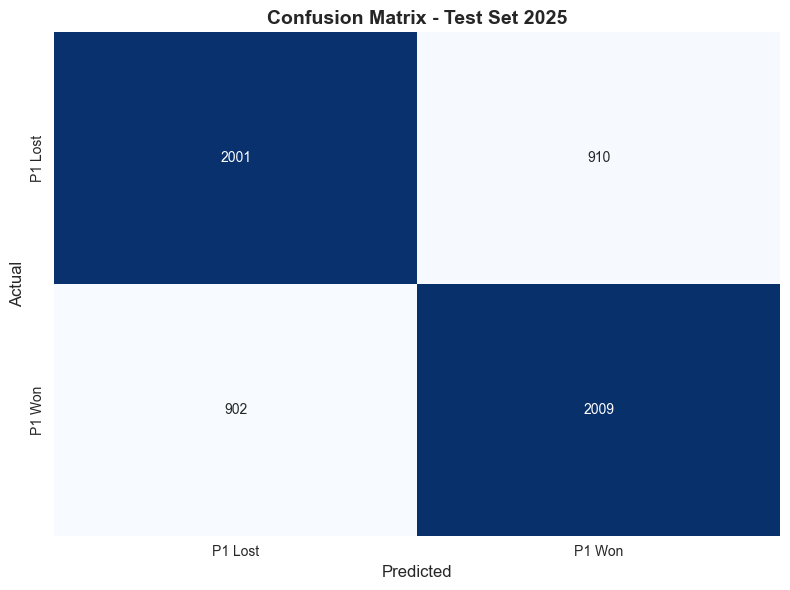


📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

     P1 Lost     0.6893    0.6874    0.6883      2911
      P1 Won     0.6882    0.6901    0.6892      2911

    accuracy                         0.6888      5822
   macro avg     0.6888    0.6888    0.6888      5822
weighted avg     0.6888    0.6888    0.6888      5822



In [ ]:
# Confusion Matrix for calibrated model
print("CONFUSION MATRIX (Calibrated XGBoost)")
print("=" * 80)

cm = confusion_matrix(y_test, y_test_pred_calibrated)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['P1 Lost', 'P1 Won'],
            yticklabels=['P1 Lost', 'P1 Won'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - Test Set 2025', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Classification Report
print("\nCLASSIFICATION REPORT:")
print("=" * 80)
print(classification_report(y_test, y_test_pred_calibrated, 
                          target_names=['P1 Lost', 'P1 Won'],
                          digits=4))
print("=" * 80)

## Step 8: Save Model

In [ ]:
import pickle

# Create models directory
models_dir = Path('../saved models')
models_dir.mkdir(exist_ok=True, parents=True)

# Save calibrated model
model_path = models_dir / 'xgboost_calibrated_model.pkl'

with open(model_path, 'wb') as f:
    pickle.dump(calibrated_xgb, f)

print("MODEL SAVED")
print("=" * 80)
print(f"Model saved: {model_path}")
print(f"Size: {model_path.stat().st_size / (1024**2):.2f} MB")

# Save feature list
features_list_path = models_dir / 'feature_columns.txt'
with open(features_list_path, 'w') as f:
    f.write('\n'.join(feature_cols))

print(f"\nFeature list saved: {features_list_path}")
print(f"Number of features: {len(feature_cols)}")

# Save metrics
metrics_path = models_dir / 'model_metrics.txt'
with open(metrics_path, 'w') as f:
    f.write("=" * 80 + "\n")
    f.write("CALIBRATED XGBOOST MODEL METRICS (Test 2025)\n")
    f.write("=" * 80 + "\n\n")
    f.write(f"Accuracy:  {accuracy_score(y_test, y_test_pred_calibrated):.4f}\n")
    f.write(f"Precision: {precision_score(y_test, y_test_pred_calibrated):.4f}\n")
    f.write(f"Recall:    {recall_score(y_test, y_test_pred_calibrated):.4f}\n")
    f.write(f"F1-Score:  {f1_score(y_test, y_test_pred_calibrated):.4f}\n")
    f.write(f"ROC-AUC:   {roc_auc_score(y_test, y_test_proba_calibrated):.4f}\n")
    f.write(f"Log Loss:  {log_loss(y_test, y_test_proba_calibrated):.4f}\n")
    f.write("\n" + "=" * 80 + "\n")

print(f"\nMetrics saved: {metrics_path}")
print("=" * 80)
print("\nAll done! Model ready for predictions!")

💾 ЗБЕРЕЖЕННЯ МОДЕЛІ
✅ Модель збережена: ../saved models/xgboost_calibrated_model.pkl
   Розмір: 0.90 MB

✅ Список features збережено: ../saved models/feature_columns.txt
   Кількість фіч: 53

✅ Метрики збережено: ../saved models/model_metrics.txt

🎉 Все готово! Модель можна використовувати для прогнозування!


## Step 9: Example Usage

In [ ]:
print("PREDICTION EXAMPLE")
print("=" * 80)

# Select random match from test set
sample_idx = np.random.randint(0, len(X_test_xgb))
sample_match = X_test_xgb.iloc[sample_idx:sample_idx+1]
actual_result = y_test.iloc[sample_idx]

# Prediction
prob_p1_wins = calibrated_xgb.predict_proba(sample_match)[0, 1]
prob_p2_wins = 1 - prob_p1_wins
prediction = calibrated_xgb.predict(sample_match)[0]

# Get player names from df_test
p1_name = df_test.iloc[sample_idx]['p1_name']
p2_name = df_test.iloc[sample_idx]['p2_name']
surface = df_test.iloc[sample_idx]['surface']
tourney = df_test.iloc[sample_idx].get('tourney_name', 'Unknown')

print(f"\nMATCH:")
print(f"  {p1_name} vs {p2_name}")
print(f"  Surface: {surface}")
print(f"  Tournament: {tourney}")

print(f"\nPREDICTION:")
print(f"  {p1_name} wins: {prob_p1_wins:.1%}")
print(f"  {p2_name} wins: {prob_p2_wins:.1%}")
print(f"\n  Predicted winner: {p1_name if prediction == 1 else p2_name}")
print(f"  Actual winner:    {p1_name if actual_result == 1 else p2_name}")

result = "CORRECT!" if prediction == actual_result else "INCORRECT"
print(f"\n  {result}")

print("\n" + "=" * 80)

🎾 ПРИКЛАД ПЕРЕДБАЧЕННЯ

📋 МАТЧ:
  Facundo Bagnis vs Arthur Rinderknech
  Surface: Clay
  Tournament: Kitzbuhel

🎯 ПРОГНОЗ:
  Facundo Bagnis wins: 36.7%
  Arthur Rinderknech wins: 63.3%

  Predicted winner: Arthur Rinderknech
  Actual winner:    Arthur Rinderknech

  ✅ ПРАВИЛЬНО!



In [ ]:
print("MODEL PERFORMANCE ANALYSIS BY MATCH TYPES")
print("=" * 80)

# Add predictions to test dataset
df_test_analysis = df_test.copy()
df_test_analysis['predicted_prob_p1'] = y_test_proba_calibrated
df_test_analysis['predicted_winner'] = y_test_pred_calibrated
df_test_analysis['actual_winner'] = y_test
df_test_analysis['correct'] = df_test_analysis['predicted_winner'] == df_test_analysis['actual_winner']

# 1. Analysis by model confidence level
print("\n1. ACCURACY BY MODEL CONFIDENCE LEVEL")
print("-" * 80)

confidence_bins = [
    ('Very confident (>70%)', 0.70, 1.00),
    ('Confident (60-70%)', 0.60, 0.70),
    ('Moderate (55-60%)', 0.55, 0.60),
    ('Uncertain (50-55%)', 0.50, 0.55),
]

for label, min_prob, max_prob in confidence_bins:
    max_prob_per_match = df_test_analysis['predicted_prob_p1'].apply(
        lambda x: max(x, 1-x)
    )
    mask = (max_prob_per_match >= min_prob) & (max_prob_per_match < max_prob)
    
    matches_in_bin = df_test_analysis[mask]
    
    if len(matches_in_bin) > 0:
        accuracy = matches_in_bin['correct'].mean()
        count = len(matches_in_bin)
        print(f"{label:<25} | Matches: {count:>5} | Accuracy: {accuracy:>6.2%}")

print("\n" + "=" * 80)

# 2. Analysis by surface
print("\n2. ACCURACY BY SURFACE")
print("-" * 80)

for surface in ['Hard', 'Clay', 'Grass', 'Carpet']:
    surface_matches = df_test_analysis[df_test_analysis['surface'] == surface]
    
    if len(surface_matches) > 0:
        accuracy = surface_matches['correct'].mean()
        count = len(surface_matches)
        avg_prob = surface_matches['predicted_prob_p1'].apply(lambda x: max(x, 1-x)).mean()
        print(f"{surface:<10} | Matches: {count:>5} | Accuracy: {accuracy:>6.2%} | Avg Confidence: {avg_prob:>6.2%}")

print("\n" + "=" * 80)

# 3. Analysis by rank difference
print("\n3. ACCURACY BY RANK DIFFERENCE")
print("-" * 80)

if 'p1_rank' in df_test_analysis.columns and 'p2_rank' in df_test_analysis.columns:
    df_test_analysis['rank_diff_abs'] = abs(
        df_test_analysis['p1_rank'].fillna(500) - df_test_analysis['p2_rank'].fillna(500)
    )
    
    rank_bins = [
        ('Clear favorite (>100)', 100, 1000),
        ('Moderate favorite (50-100)', 50, 100),
        ('Slight favorite (20-50)', 20, 50),
        ('Even match (<20)', 0, 20),
    ]
    
    for label, min_diff, max_diff in rank_bins:
        mask = (df_test_analysis['rank_diff_abs'] >= min_diff) & (df_test_analysis['rank_diff_abs'] < max_diff)
        matches = df_test_analysis[mask]
        
        if len(matches) > 0:
            accuracy = matches['correct'].mean()
            count = len(matches)
            avg_prob = matches['predicted_prob_p1'].apply(lambda x: max(x, 1-x)).mean()
            print(f"{label:<30} | Matches: {count:>5} | Accuracy: {accuracy:>6.2%} | Avg Confidence: {avg_prob:>6.2%}")
else:
    print("Rank columns not found")

print("\n" + "=" * 80)

# 4. Best predictions analysis
print("\n4. BEST PREDICTIONS (highest confidence + correct)")
print("-" * 80)

correct_predictions = df_test_analysis[df_test_analysis['correct'] == True].copy()
correct_predictions['max_prob'] = correct_predictions['predicted_prob_p1'].apply(lambda x: max(x, 1-x))
best_predictions = correct_predictions.nlargest(5, 'max_prob')

for idx, row in best_predictions.iterrows():
    p1_prob = row['predicted_prob_p1']
    p2_prob = 1 - p1_prob
    winner = row['p1_name'] if row['predicted_winner'] == 1 else row['p2_name']
    confidence = max(p1_prob, p2_prob)
    
    print(f"{row['p1_name']:<25} vs {row['p2_name']:<25}")
    print(f"   Predicted: {winner:<25} ({confidence:.1%}) | Surface: {row['surface']}")
    print()

print("=" * 80)

print("\n5. ERROR STATISTICS")
print("-" * 80)

incorrect_predictions = df_test_analysis[df_test_analysis['correct'] == False].copy()
incorrect_predictions['max_prob'] = incorrect_predictions['predicted_prob_p1'].apply(lambda x: max(x, 1-x))

print(f"Total errors: {len(incorrect_predictions)} of {len(df_test_analysis)} ({len(incorrect_predictions)/len(df_test_analysis)*100:.1f}%)")
print(f"\nAverage confidence in incorrect predictions: {incorrect_predictions['max_prob'].mean():.1%}")
print(f"Average confidence in correct predictions: {correct_predictions['max_prob'].mean():.1%}")

# Top-5 most confident errors
print(f"\nTOP-5 MOST CONFIDENT ERRORS:")
print("-" * 80)

worst_predictions = incorrect_predictions.nlargest(5, 'max_prob')

for idx, row in worst_predictions.iterrows():
    p1_prob = row['predicted_prob_p1']
    p2_prob = 1 - p1_prob
    predicted_winner = row['p1_name'] if row['predicted_winner'] == 1 else row['p2_name']
    actual_winner = row['p1_name'] if row['actual_winner'] == 1 else row['p2_name']
    confidence = max(p1_prob, p2_prob)
    
    print(f"{row['p1_name']:<25} vs {row['p2_name']:<25}")
    print(f"   Predicted: {predicted_winner:<25} ({confidence:.1%})")
    print(f"   Actual:    {actual_winner:<25} | Surface: {row['surface']}")
    print()

print("=" * 80)

📊 АНАЛІЗ ПРОДУКТИВНОСТІ МОДЕЛІ ЗА ТИПАМИ МАТЧІВ

🎯 1. ACCURACY ЗА РІВНЕМ ВПЕВНЕНОСТІ МОДЕЛІ
--------------------------------------------------------------------------------
Дуже впевнена (>70%)      | Матчів:  2481 | Accuracy: 73.68%
Впевнена (60-70%)         | Матчів:  1515 | Accuracy: 62.51%
Помірна (55-60%)          | Матчів:   567 | Accuracy: 58.55%
Невпевнена (50-55%)       | Матчів:   739 | Accuracy: 52.23%


🎾 2. ACCURACY ЗА ПОВЕРХНЯМИ
--------------------------------------------------------------------------------
Hard       | Матчів:  3654 | Accuracy: 69.13% | Avg Confidence: 74.18%
Clay       | Матчів:  1574 | Accuracy: 68.49% | Avg Confidence: 73.02%
Grass      | Матчів:   594 | Accuracy: 68.35% | Avg Confidence: 73.78%


📊 3. ACCURACY ЗА РІЗНИЦЕЮ РАНГІВ
--------------------------------------------------------------------------------
Великий фаворит (>100)         | Матчів:  1190 | Accuracy: 71.51% | Avg Confidence: 80.40%
Середній фаворит (50-100)      | Матчів:  1420 | Acc

## Summary

### Completed:

1. **Baseline RandomForest** - fast model with good results
2. **XGBoost** - improved model with gradient boosting
3. **Hyperparameter Tuning** - optimized parameters
4. **Probability Calibration** - accurate probabilities for betting
5. **Feature Importance** - analysis of most important features
6. **Model Evaluation** - detailed metrics and comparison

### Key Metrics:

- **Accuracy**: prediction accuracy
- **ROC-AUC**: classification quality (>0.7 = good)
- **Log Loss**: probability quality (lower = better)
- **Calibration**: how accurate are probabilities

### Next Steps:

1. **Final tuning** - GridSearchCV for optimal parameters
2. **Ensemble models** - combine RandomForest + XGBoost
3. **Deep Learning** - try neural networks
4. **Real-time predictions** - API for predictions
5. **Betting strategy** - strategy based on probabilities